In [ ]:
# Ensure dependencies are installed
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn statmodels

from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm


# Set up file paths
drive_dir = r'/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'DatasetsCombinedCommonPeriodMatrix.xlsx')

# Function to load the dataset
def load_data(file_path):
    try:
        # Load the Excel file
        data = pd.read_excel(file_path, sheet_name="DatasetsCombinedCommonPeriodMat", index_col=0)

        # Ensure the Date column is datetime
        data.index = pd.to_datetime(data.index, errors='coerce')

        # Extract Portfolio, Benchmark, and other matrices based on column naming
        portfolio_returns = data.filter(like='.PortfolioReturnMatrix')
        benchmark_returns = data.filter(like='.BenchmarkReturnMatrix')
        index_data = data.filter(like='.OutperformanceMatrix')

        return {
            "PortfolioReturnMatrix": portfolio_returns,
            "BenchmarkReturnMatrix": benchmark_returns,
            "IndexData": index_data
        }

    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# Function to perform regressions
def factorize_regression(common_period_matrix):
    """
    Perform regression on the outputs of the common period matrix preprocessing.

    Parameters:
    common_period_matrix (dict): A dictionary containing aligned return matrices:
        {
            'PortfolioReturnMatrix': DataFrame,
            'BenchmarkReturnMatrix': DataFrame,
            'IndexData': DataFrame
        }

    Returns:
    list: A list of regression results for each portfolio.
    """
    portfolio_returns = common_period_matrix['PortfolioReturnMatrix']
    benchmark_returns = common_period_matrix['BenchmarkReturnMatrix']
    index_data = common_period_matrix['IndexData']

    # Ensure alignment of index_data with portfolio_returns
    index_data = index_data.loc[portfolio_returns.index]

    results = []

    for col in portfolio_returns.columns:
        mandate_returns = portfolio_returns[col]

        # Design matrix includes outperformance data
        X = sm.add_constant(index_data)
        y = mandate_returns

        # Check for valid data
        if y.isna().all() or X.isna().all().any():
            print(f"Skipping regression for {col} due to insufficient data.")
            continue

        # Perform regression
        model = sm.OLS(y, X, missing='drop')
        regression_result = model.fit()

        results.append({
            'Mandate': col,
            'RegressionSummary': regression_result.summary().as_text(),
            'Parameters': regression_result.params,
            'PValues': regression_result.pvalues,
            'RSquared': regression_result.rsquared
        })

    return results

# Main execution block
if __name__ == "__main__":
    # Load the data
    data_matrices = load_data(file_path)

    if data_matrices:
        # Perform regression
        regression_results = factorize_regression(data_matrices)

        # Display summaries of the first few regressions
        for result in regression_results[:3]:  # Display only the first 3 regressions for brevity
            print(f"Regression for {result['Mandate']}")
            print(result['RegressionSummary'])
            print("\n" + "="*80 + "\n")
    else:
        print("Failed to load the data. Please check the file format and structure.")



ERROR: Could not find a version that satisfies the requirement statmodels (from versions: none)
ERROR: No matching distribution found for statmodels
Mounted at /content/drive
Regression for Valora PK - Aktien Schweiz Small and Mid Caps (Pictet).PortfolioReturnMatrix
                                                         OLS Regression Results                                                         
Dep. Variable:     Valora PK - Aktien Schweiz Small and Mid Caps (Pictet).PortfolioReturnMatrix   R-squared:                       0.994
Model:                                                                                      OLS   Adj. R-squared:                  0.993
Method:                                                                           Least Squares   F-statistic:                     635.6
Date:                                                                          Tue, 26 Nov 2024   Prob (F-statistic):           1.40e-86
Time:                                           

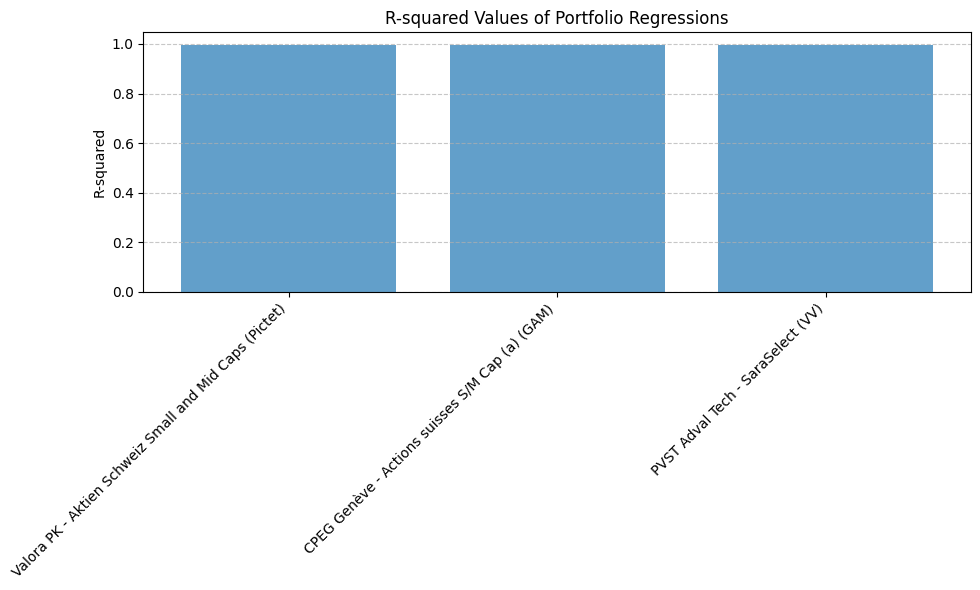

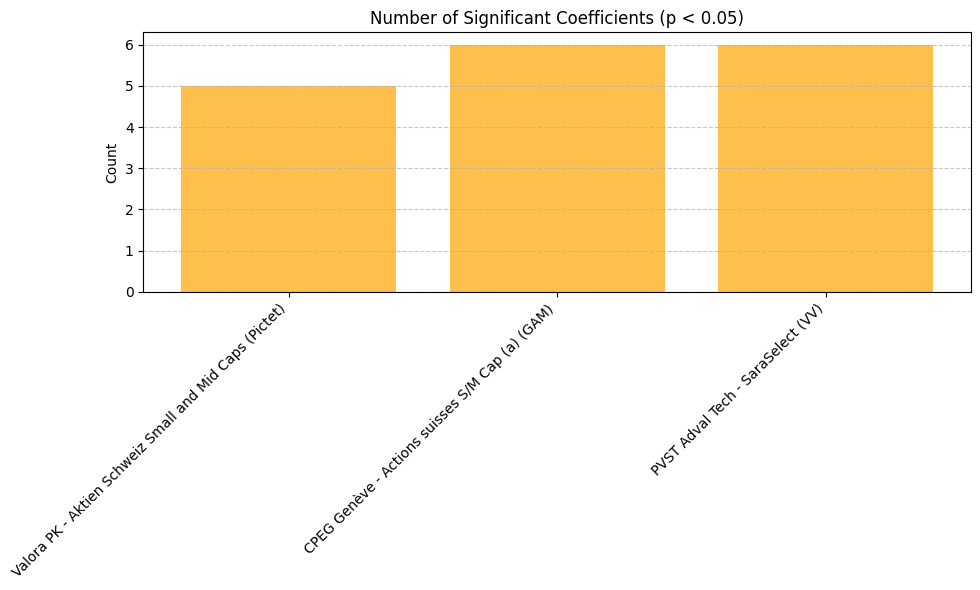

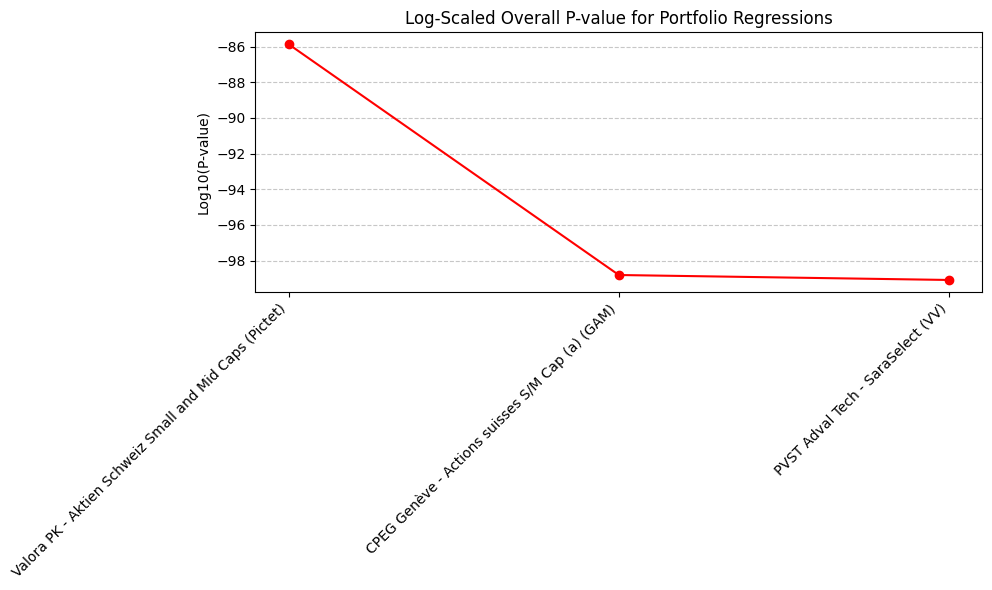

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Example regression data (summary of key metrics for illustration purposes)
# Replace with actual coefficients, R-squared, and p-values
data = {
    "Portfolio": [
        "Valora PK - Aktien Schweiz Small and Mid Caps (Pictet)",
        "CPEG Genève - Actions suisses S/M Cap (a) (GAM)",
        "PVST Adval Tech - SaraSelect (VV)"
    ],
    "R_squared": [0.994, 0.997, 0.997],
    "Significant Coefficients": [5, 6, 6],  # Count of predictors with p < 0.05
    "P_value_Overall": [1.40e-86, 1.54e-99, 8.11e-100],  # Prob (F-statistic)
}

# Convert to DataFrame for visualization
df_results = pd.DataFrame(data)

# Bar Chart for R-squared values
plt.figure(figsize=(10, 6))
plt.bar(df_results["Portfolio"], df_results["R_squared"], alpha=0.7)
plt.title("R-squared Values of Portfolio Regressions")
plt.ylabel("R-squared")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Bar Chart for Significant Coefficients
plt.figure(figsize=(10, 6))
plt.bar(df_results["Portfolio"], df_results["Significant Coefficients"], alpha=0.7, color="orange")
plt.title("Number of Significant Coefficients (p < 0.05)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Line Plot for Overall P-value (log scale to emphasize small differences)
plt.figure(figsize=(10, 6))
plt.plot(df_results["Portfolio"], np.log10(df_results["P_value_Overall"]), marker='o', linestyle='-', color='red')
plt.title("Log-Scaled Overall P-value for Portfolio Regressions")
plt.ylabel("Log10(P-value)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def compute_vif(data):
    """
    Compute Variance Inflation Factor (VIF) for each feature in a dataset.
    Args:
        data (pd.DataFrame): DataFrame containing independent variables.
    Returns:
        pd.DataFrame: VIF scores for each variable.
    """
    # Add constant term for the intercept in the regression
    X = add_constant(data)

    # Compute VIF for each variable
    vif_data = pd.DataFrame({
        "Variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })

    return vif_data.drop(index=0)  # Drop constant (intercept)


# Example: Compute VIF for each portfolio
def compute_vif_per_portfolio(data_matrices):
    """
    Compute VIF for predictors in the regression model of each portfolio.

    Args:
        data_matrices (dict): A dictionary containing aligned return matrices:
            - 'PortfolioReturnMatrix': DataFrame
            - 'IndexData': DataFrame

    Returns:
        dict: A dictionary of VIF scores per portfolio.
    """
    portfolio_returns = data_matrices["PortfolioReturnMatrix"]
    index_data = data_matrices["IndexData"]

    vif_results = {}

    for col in portfolio_returns.columns:
        mandate_returns = portfolio_returns[col]

        # Design matrix includes outperformance data
        predictors = index_data

        if predictors.isna().all().any() or mandate_returns.isna().all():
            print(f"Skipping {col} due to missing data.")
            continue

        vif_results[col] = compute_vif(predictors)

    return vif_results


# Load your data (replace with actual data loading function)
data_matrices = load_data(file_path)  # Replace with actual path

# Compute VIF for all portfolios
if data_matrices:
    vif_results_per_portfolio = compute_vif_per_portfolio(data_matrices)
    for portfolio, vif_result in vif_results_per_portfolio.items():
        print(f"VIF for {portfolio}:")
        print(vif_result)
        print("="*80)


VIF for Valora PK - Aktien Schweiz Small and Mid Caps (Pictet).PortfolioReturnMatrix:
                                             Variable          VIF
1   Valora PK - Aktien Schweiz Small and Mid Caps ...    46.142715
2   CPEG GenÃ¨ve - Actions suisses S/M Cap (a) (GA...   156.758063
3   PVST Adval Tech - SaraSelect (VV).Outperforman...    90.656226
4   Pensionskasse Kanton Solothurn - Aktien Schwei...   143.470985
5   Pensionskasse der Stadt Luzern - Aktien Schwei...   112.929283
6   Skycare - Actions Suisse S&M Cap (a) (zCapital...   104.761943
7   APK - Aktien Schweiz (Intern).OutperformanceMa...    14.785247
8   Pensionskasse SRG SSR - Aktien Schweiz (IAM).O...     7.744386
9   PKBS - Aktien Schweiz IsoPro aktiv (SGKB).Outp...  2590.312286
10  Helsana-Gruppe - Gruppe Aktien CH (Intern).Out...    90.114369
11  Post - Aktien Schweiz (Finreon).Outperformance...  2983.626175
12  AGV Aargauische GebÃ¤udeversicherung - Aktien ...    42.038129
13  Valora PK - Aktien Schweiz Small and Mi

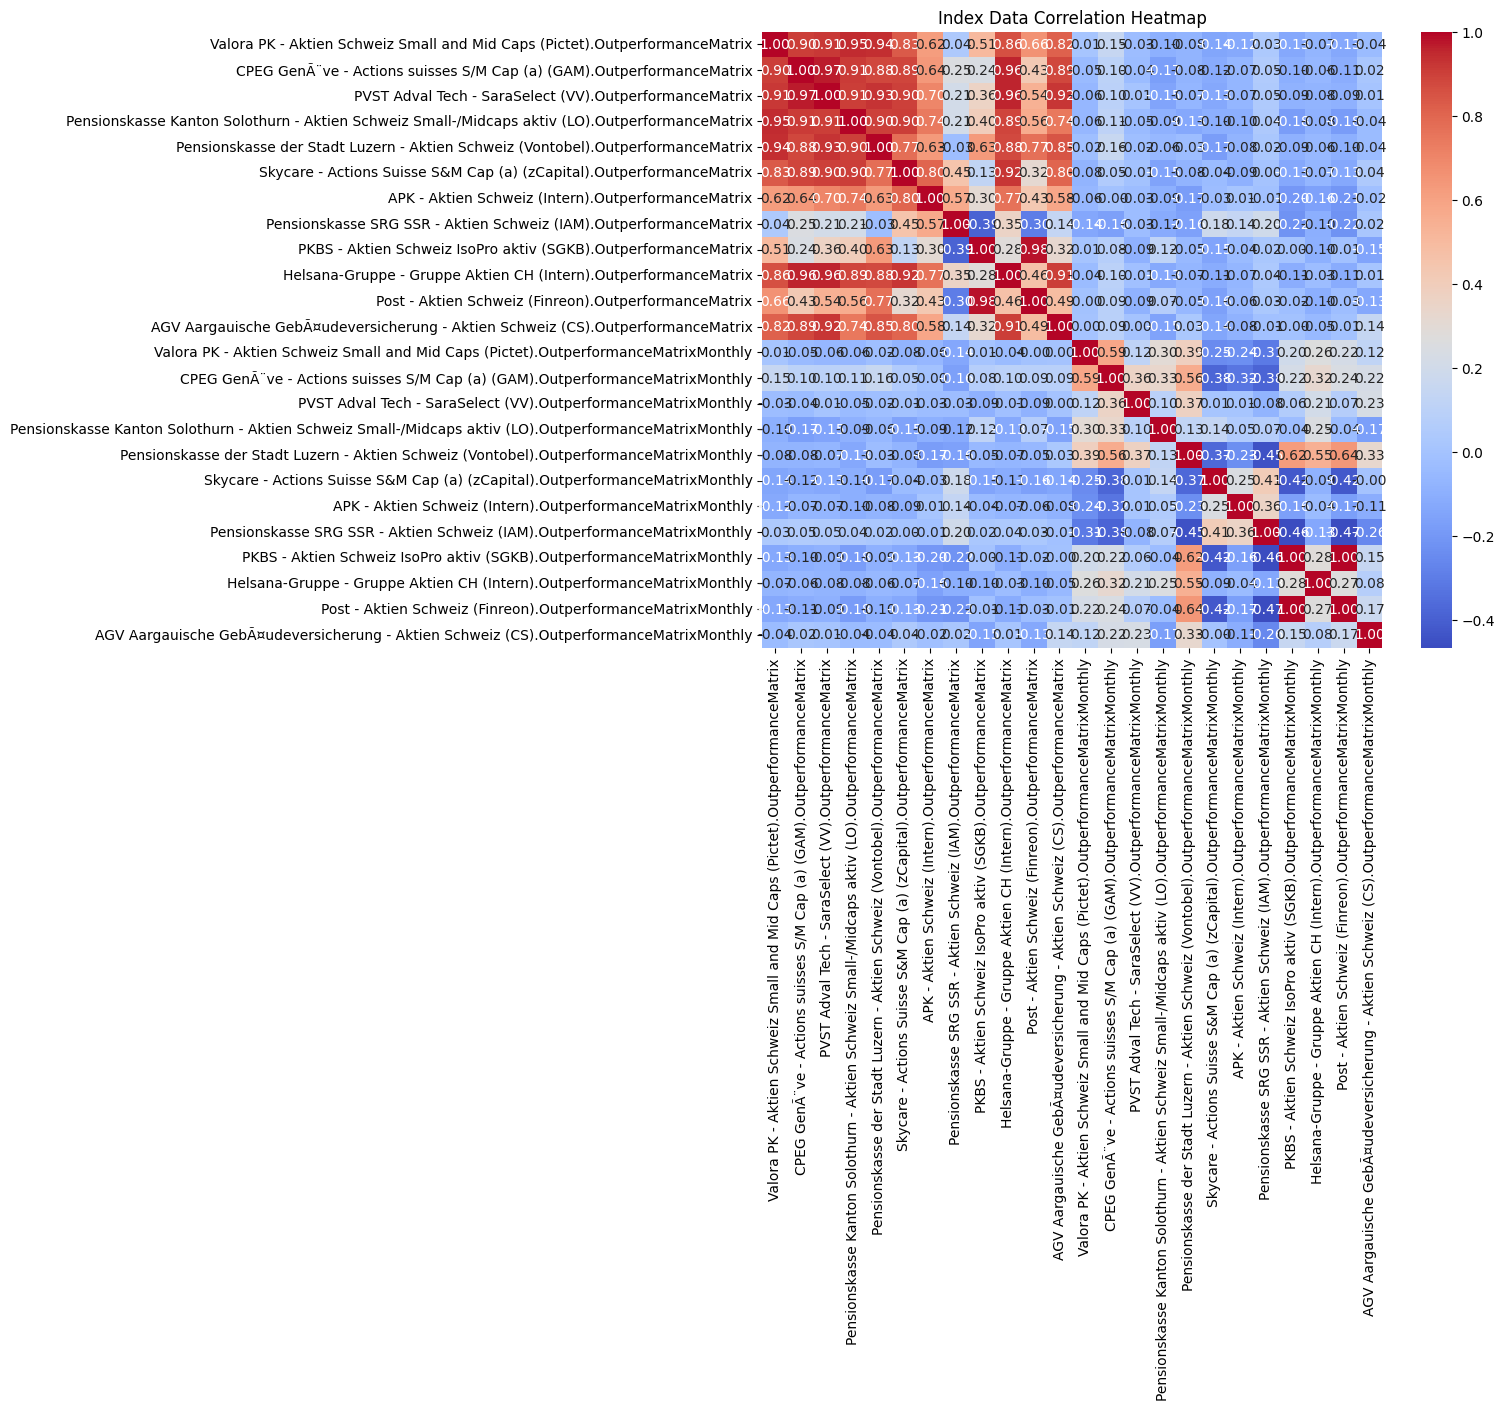

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_heatmap(data, title="Correlation Heatmap"):
    """
    Plot a correlation heatmap for the predictors.

    Args:
        data (pd.DataFrame): DataFrame of predictors.
        title (str): Title of the heatmap.
    """
    corr_matrix = data.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(title)
    plt.show()

# Example usage
index_data = data_matrices["IndexData"]  # Replace with your dataset
plot_correlation_heatmap(index_data, title="Index Data Correlation Heatmap")


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import pandas as pd
import os
import statsmodels.api as sm

# Set up file paths
drive_dir = '/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'DatasetsCombinedCommonPeriodMatrix.xlsx')

# Define function to load the dataset
def load_data(file_path):
    """
    Load the dataset from an Excel file.
    """
    try:
        # Load the Excel file
        data = pd.read_excel(file_path, sheet_name="DatasetsCombinedCommonPeriodMat", index_col=0)

        # Ensure the Date column is datetime
        data.index = pd.to_datetime(data.index, errors='coerce')

        # Extract Portfolio, Benchmark, and other matrices based on column naming
        portfolio_returns = data.filter(like='.PortfolioReturnMatrix')
        benchmark_returns = data.filter(like='.BenchmarkReturnMatrix')

        return {
            "PortfolioReturnMatrix": portfolio_returns,
            "BenchmarkReturnMatrix": benchmark_returns,
        }
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# Function to compare all portfolios to all benchmarks
def compare_portfolios_to_benchmarks(data_matrices):
    """
    Compare all portfolios to all benchmarks independently.

    Parameters:
    - data_matrices: dict, containing PortfolioReturnMatrix and BenchmarkReturnMatrix.

    Returns:
    - results: DataFrame summarizing regression results for each portfolio vs. each benchmark.
    """
    portfolio_returns = data_matrices['PortfolioReturnMatrix']
    benchmark_returns = data_matrices['BenchmarkReturnMatrix']

    results = []

    for portfolio in portfolio_returns.columns:
        for benchmark in benchmark_returns.columns:
            # Align data
            aligned_data = pd.concat([portfolio_returns[portfolio], benchmark_returns[benchmark]], axis=1).dropna()
            if aligned_data.empty:
                print(f"No overlapping data for Portfolio: {portfolio}, Benchmark: {benchmark}")
                continue

            y = aligned_data[portfolio]
            X = sm.add_constant(aligned_data[benchmark])  # Add intercept

            # Perform regression
            try:
                model = sm.OLS(y, X).fit()
                # Collect results
                results.append({
                    "Portfolio": portfolio,
                    "Benchmark": benchmark,
                    "Beta": model.params[1],  # Coefficient for the benchmark
                    "R-squared": model.rsquared,
                    "P-value": model.pvalues[1],  # P-value for the benchmark coefficient
                })
            except Exception as e:
                print(f"Error processing Portfolio: {portfolio}, Benchmark: {benchmark}: {e}")
                continue

    return pd.DataFrame(results)

# Load the data
data_matrices = load_data(file_path)

# Perform the analysis
if data_matrices:
    comparison_results = compare_portfolios_to_benchmarks(data_matrices)

    # Display results
    print("Regression Results Summary:")
    print(comparison_results)

    # Save results to CSV
    comparison_results.to_csv(os.path.join(drive_dir, 'Portfolio_Benchmark_Comparison.csv'), index=False)
    print(f"Results saved to {drive_dir}/Portfolio_Benchmark_Comparison.csv")
else:
    print("Failed to load data. Please check file path and structure.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-6-d7d23dbac932>:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": model.params[1],  # Coefficient for the benchmark
<ipython-input-6-d7d23dbac932>:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "P-value": model.pvalues[1],  # P-value for the benchmark coefficient
<ipython-input-6-d7d23dbac932>:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": model.params[1],  # Coefficient for the benchmark
<ipytho

Regression Results Summary:
                                             Portfolio  \
0    Valora PK - Aktien Schweiz Small and Mid Caps ...   
1    Valora PK - Aktien Schweiz Small and Mid Caps ...   
2    Valora PK - Aktien Schweiz Small and Mid Caps ...   
3    Valora PK - Aktien Schweiz Small and Mid Caps ...   
4    Valora PK - Aktien Schweiz Small and Mid Caps ...   
..                                                 ...   
571  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   
572  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   
573  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   
574  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   
575  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   

                                             Benchmark      Beta  R-squared  \
0    Valora PK - Aktien Schweiz Small and Mid Caps ...  1.291618   0.996312   
1    CPEG GenÃ¨ve - Actions suisses S/M Cap (a) (GA...  1.307726   0.994397   
2    PVST Adval Tech - SaraSelect (VV)

<ipython-input-6-d7d23dbac932>:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": model.params[1],  # Coefficient for the benchmark
<ipython-input-6-d7d23dbac932>:74: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "P-value": model.pvalues[1],  # P-value for the benchmark coefficient
<ipython-input-6-d7d23dbac932>:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": model.params[1],  # Coefficient for the benchmark
<ipytho

<ipython-input-8-c4e550ab4e3b>:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": model.params[1],  # Coefficient for the benchmark
<ipython-input-8-c4e550ab4e3b>:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "P-value": model.pvalues[1],  # P-value for the benchmark coefficient
<ipython-input-8-c4e550ab4e3b>:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Beta": model.params[1],  # Coefficient for the benchmark
<ipytho

Regression Results Summary:
                                             Portfolio  \
0    Valora PK - Aktien Schweiz Small and Mid Caps ...   
1    Valora PK - Aktien Schweiz Small and Mid Caps ...   
2    Valora PK - Aktien Schweiz Small and Mid Caps ...   
3    Valora PK - Aktien Schweiz Small and Mid Caps ...   
4    Valora PK - Aktien Schweiz Small and Mid Caps ...   
..                                                 ...   
571  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   
572  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   
573  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   
574  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   
575  AGV Aargauische GebÃ¤udeversicherung - Aktien ...   

                                             Benchmark      Beta  R-squared  \
0    Valora PK - Aktien Schweiz Small and Mid Caps ...  1.291618   0.996312   
1    CPEG GenÃ¨ve - Actions suisses S/M Cap (a) (GA...  1.307726   0.994397   
2    PVST Adval Tech - SaraSelect (VV)

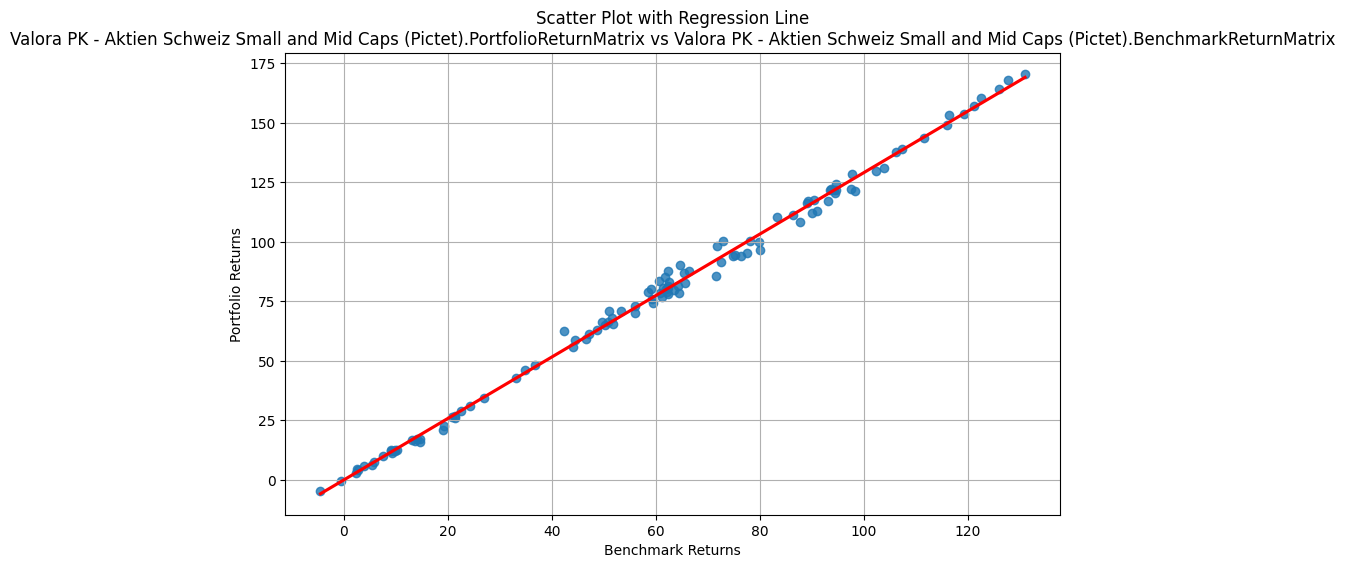

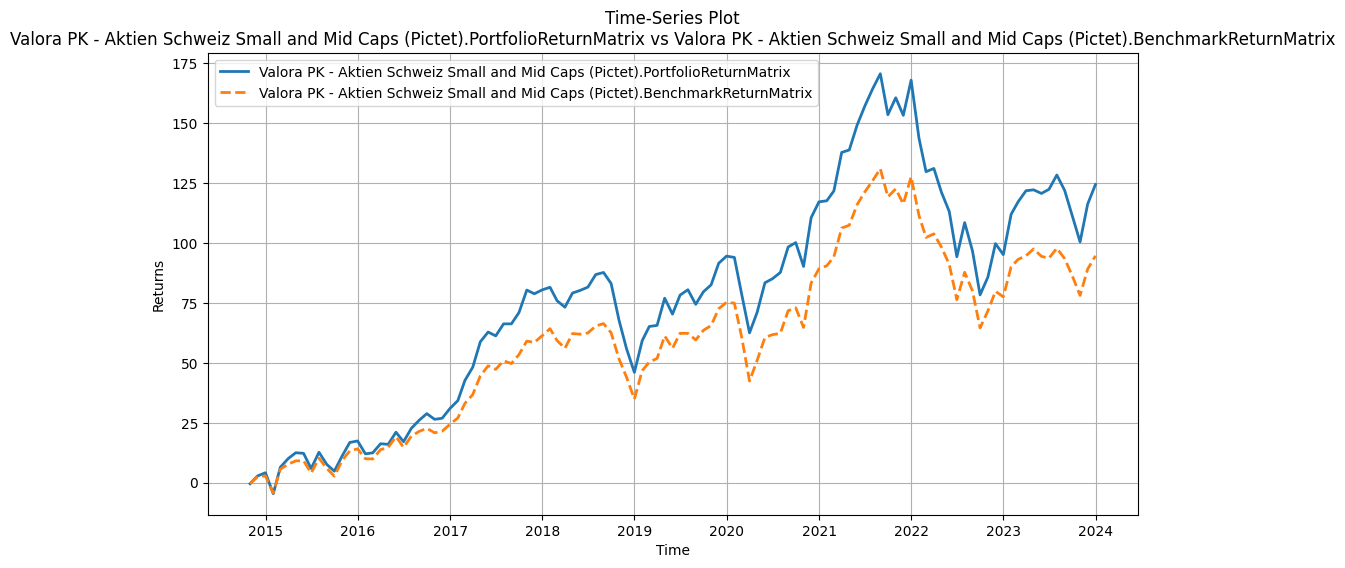

In [ ]:
import pandas as pd
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Set up file paths
drive_dir = '/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'DatasetsCombinedCommonPeriodMatrix.xlsx')

# Function to load the dataset
def load_data(file_path):
    """
    Load the dataset from an Excel file.
    """
    try:
        # Load the Excel file
        data = pd.read_excel(file_path, sheet_name="DatasetsCombinedCommonPeriodMat", index_col=0)

        # Ensure the Date column is datetime
        data.index = pd.to_datetime(data.index, errors='coerce')

        # Extract Portfolio, Benchmark, and other matrices based on column naming
        portfolio_returns = data.filter(like='.PortfolioReturnMatrix')
        benchmark_returns = data.filter(like='.BenchmarkReturnMatrix')

        return {
            "PortfolioReturnMatrix": portfolio_returns,
            "BenchmarkReturnMatrix": benchmark_returns,
        }
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# Function to compare all portfolios to all benchmarks
def compare_portfolios_to_benchmarks(data_matrices):
    """
    Compare all portfolios to all benchmarks independently.

    Parameters:
    - data_matrices: dict, containing PortfolioReturnMatrix and BenchmarkReturnMatrix.

    Returns:
    - results: DataFrame summarizing regression results for each portfolio vs. each benchmark.
    """
    portfolio_returns = data_matrices['PortfolioReturnMatrix']
    benchmark_returns = data_matrices['BenchmarkReturnMatrix']

    results = []

    for portfolio in portfolio_returns.columns:
        for benchmark in benchmark_returns.columns:
            # Align data
            aligned_data = pd.concat([portfolio_returns[portfolio], benchmark_returns[benchmark]], axis=1).dropna()
            if aligned_data.empty:
                print(f"No overlapping data for Portfolio: {portfolio}, Benchmark: {benchmark}")
                continue

            y = aligned_data[portfolio]
            X = sm.add_constant(aligned_data[benchmark])  # Add intercept

            # Perform regression
            try:
                model = sm.OLS(y, X).fit()
                # Collect results
                results.append({
                    "Portfolio": portfolio,
                    "Benchmark": benchmark,
                    "Beta": model.params[1],  # Coefficient for the benchmark
                    "R-squared": model.rsquared,
                    "P-value": model.pvalues[1],  # P-value for the benchmark coefficient
                })
            except Exception as e:
                print(f"Error processing Portfolio: {portfolio}, Benchmark: {benchmark}: {e}")
                continue

    return pd.DataFrame(results)

# Visualization function
def visualize_portfolio_vs_benchmark(data_matrices, portfolio_col, benchmark_col):
    """
    Visualize the relationship between a portfolio and a benchmark.

    Parameters:
    - data_matrices: dict, containing PortfolioReturnMatrix and BenchmarkReturnMatrix.
    - portfolio_col: str, column name of the portfolio to visualize.
    - benchmark_col: str, column name of the benchmark to visualize.
    """
    portfolio_returns = data_matrices['PortfolioReturnMatrix'][portfolio_col]
    benchmark_returns = data_matrices['BenchmarkReturnMatrix'][benchmark_col]

    # Align data
    aligned_data = pd.concat([portfolio_returns, benchmark_returns], axis=1).dropna()
    aligned_data.columns = ['Portfolio', 'Benchmark']

    # Scatter plot with regression line
    plt.figure(figsize=(10, 6))
    sns.regplot(x='Benchmark', y='Portfolio', data=aligned_data, line_kws={"color": "red"}, ci=None)
    plt.title(f"Scatter Plot with Regression Line\n{portfolio_col} vs {benchmark_col}")
    plt.xlabel("Benchmark Returns")
    plt.ylabel("Portfolio Returns")
    plt.grid()
    plt.show()

    # Time-series line plot
    plt.figure(figsize=(12, 6))
    plt.plot(aligned_data.index, aligned_data['Portfolio'], label=portfolio_col, linewidth=2)
    plt.plot(aligned_data.index, aligned_data['Benchmark'], label=benchmark_col, linestyle="--", linewidth=2)
    plt.title(f"Time-Series Plot\n{portfolio_col} vs {benchmark_col}")
    plt.xlabel("Time")
    plt.ylabel("Returns")
    plt.legend()
    plt.grid()
    plt.show()

# Main execution block
if __name__ == "__main__":
    # Load the data
    data_matrices = load_data(file_path)

    if data_matrices:
        # Perform the analysis
        comparison_results = compare_portfolios_to_benchmarks(data_matrices)

        # Display results
        print("Regression Results Summary:")
        print(comparison_results)

        # Save results to CSV
        comparison_results.to_csv(os.path.join(drive_dir, 'Portfolio_Benchmark_Comparison.csv'), index=False)
        print(f"Results saved to {drive_dir}/Portfolio_Benchmark_Comparison.csv")

        # Visualization example: Replace with actual column names
        portfolio_example = data_matrices['PortfolioReturnMatrix'].columns[0]
        benchmark_example = data_matrices['BenchmarkReturnMatrix'].columns[0]
        visualize_portfolio_vs_benchmark(data_matrices, portfolio_example, benchmark_example)
    else:
        print("Failed to load data. Please check file path and structure.")


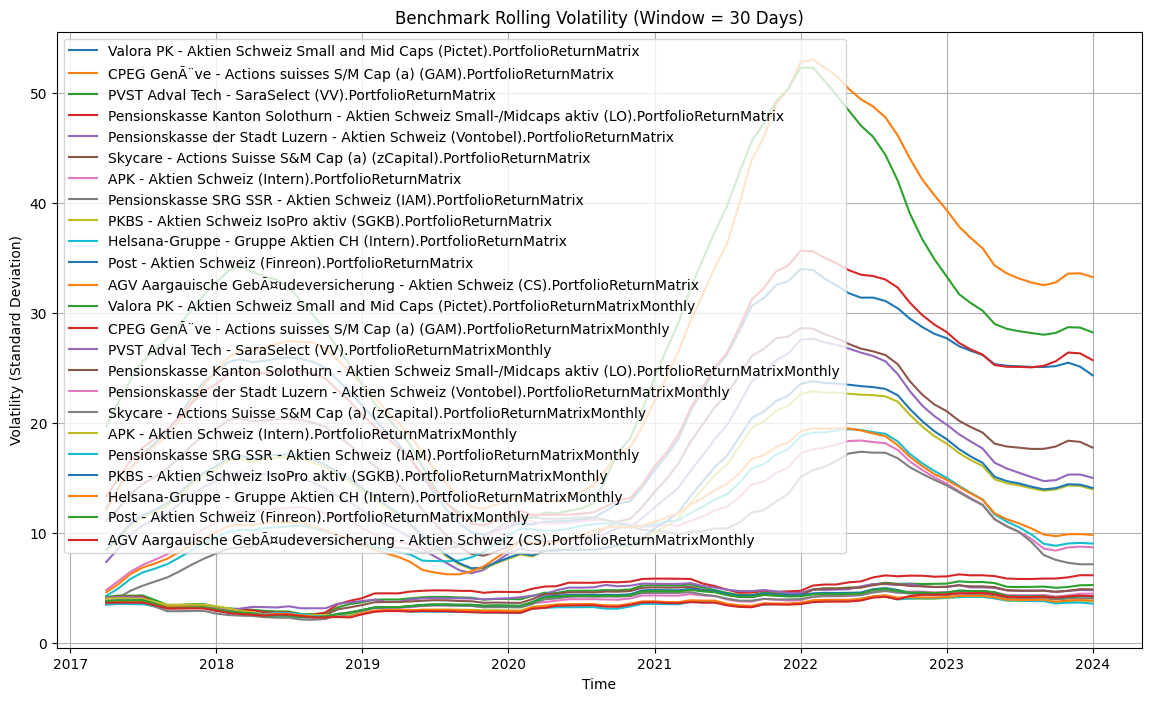

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_benchmark_volatility(data_matrices, window=30):
    """
    Analyze and visualize benchmark volatility trends using rolling standard deviation.

    Parameters:
    - data_matrices: dict, containing BenchmarkReturnMatrix.
    - window: int, rolling window size (default is 30).

    Displays:
    - Line plot of rolling volatility for each benchmark.
    """
    # Extract the benchmark return matrix
    benchmark_returns = data_matrices['PortfolioReturnMatrix']

    # Calculate rolling volatility
    rolling_volatility = benchmark_returns.rolling(window=window).std()

    # Plot rolling volatility
    plt.figure(figsize=(14, 8))
    for column in rolling_volatility.columns:
        plt.plot(rolling_volatility.index, rolling_volatility[column], label=column)

    plt.title(f"Benchmark Rolling Volatility (Window = {window} Days)")
    plt.xlabel("Time")
    plt.ylabel("Volatility (Standard Deviation)")
    plt.legend()
    plt.grid()
    plt.show()

# Main execution block
if __name__ == "__main__":
    # Load the data
    data_matrices = load_data(file_path)

    if data_matrices:
        # Analyze and visualize benchmark volatility
        analyze_benchmark_volatility(data_matrices, window=30)
    else:
        print("Failed to load data. Please check file path and structure.")



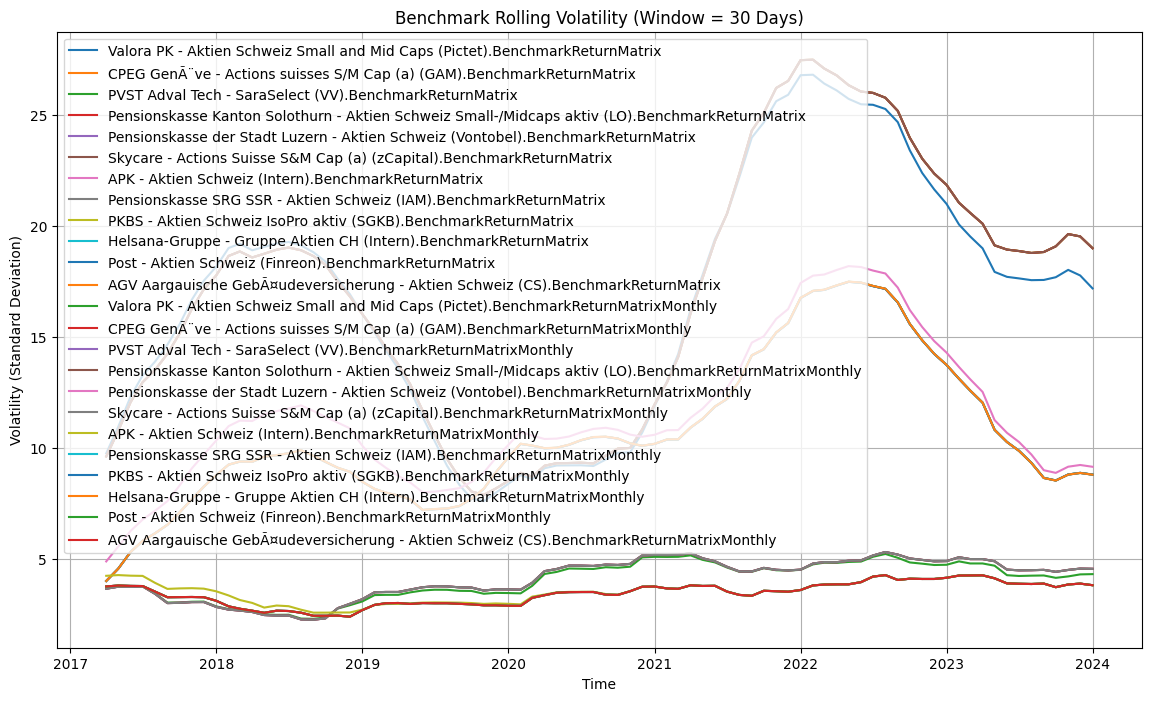

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_benchmark_volatility(data_matrices, window=30):
    """
    Analyze and visualize benchmark volatility trends using rolling standard deviation.

    Parameters:
    - data_matrices: dict, containing BenchmarkReturnMatrix.
    - window: int, rolling window size (default is 30).

    Displays:
    - Line plot of rolling volatility for each benchmark.
    """
    # Extract the benchmark return matrix
    benchmark_returns = data_matrices['BenchmarkReturnMatrix']

    # Calculate rolling volatility
    rolling_volatility = benchmark_returns.rolling(window=window).std()

    # Plot rolling volatility
    plt.figure(figsize=(14, 8))
    for column in rolling_volatility.columns:
        plt.plot(rolling_volatility.index, rolling_volatility[column], label=column)

    plt.title(f"Benchmark Rolling Volatility (Window = {window} Days)")
    plt.xlabel("Time")
    plt.ylabel("Volatility (Standard Deviation)")
    plt.legend()
    plt.grid()
    plt.show()

# Main execution block
if __name__ == "__main__":
    # Load the data
    data_matrices = load_data(file_path)

    if data_matrices:
        # Analyze and visualize benchmark volatility
        analyze_benchmark_volatility(data_matrices, window=30)
    else:
        print("Failed to load data. Please check file path and structure.")


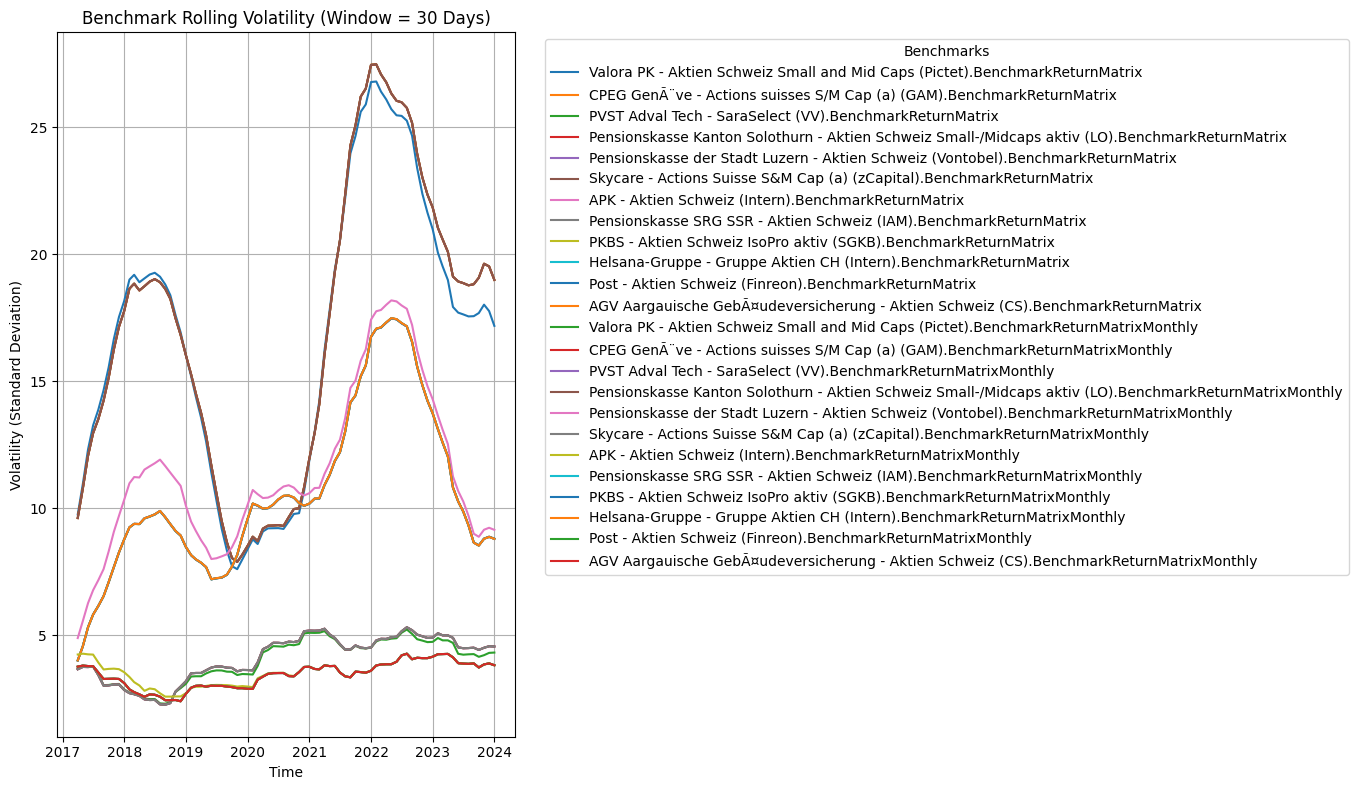

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_benchmark_volatility(data_matrices, window=30):
    """
    Analyze and visualize benchmark volatility trends using rolling standard deviation.

    Parameters:
    - data_matrices: dict, containing BenchmarkReturnMatrix.
    - window: int, rolling window size (default is 30).

    Displays:
    - Line plot of rolling volatility for each benchmark with legend outside the plot.
    """
    # Extract the benchmark return matrix
    benchmark_returns = data_matrices['BenchmarkReturnMatrix']

    # Calculate rolling volatility
    rolling_volatility = benchmark_returns.rolling(window=window).std()

    # Plot rolling volatility
    plt.figure(figsize=(14, 8))
    for column in rolling_volatility.columns:
        plt.plot(rolling_volatility.index, rolling_volatility[column], label=column)

    # Customize the plot
    plt.title(f"Benchmark Rolling Volatility (Window = {window} Days)")
    plt.xlabel("Time")
    plt.ylabel("Volatility (Standard Deviation)")
    plt.grid()

    # Place the legend outside the plot
    plt.legend(loc="upper left", bbox_to_anchor=(1.05, 1), title="Benchmarks")
    plt.tight_layout()
    plt.show()

# Main execution block
if __name__ == "__main__":
    # Load the data
    data_matrices = load_data(file_path)

    if data_matrices:
        # Analyze and visualize benchmark volatility
        analyze_benchmark_volatility(data_matrices, window=30)
    else:
        print("Failed to load data. Please check file path and structure.")



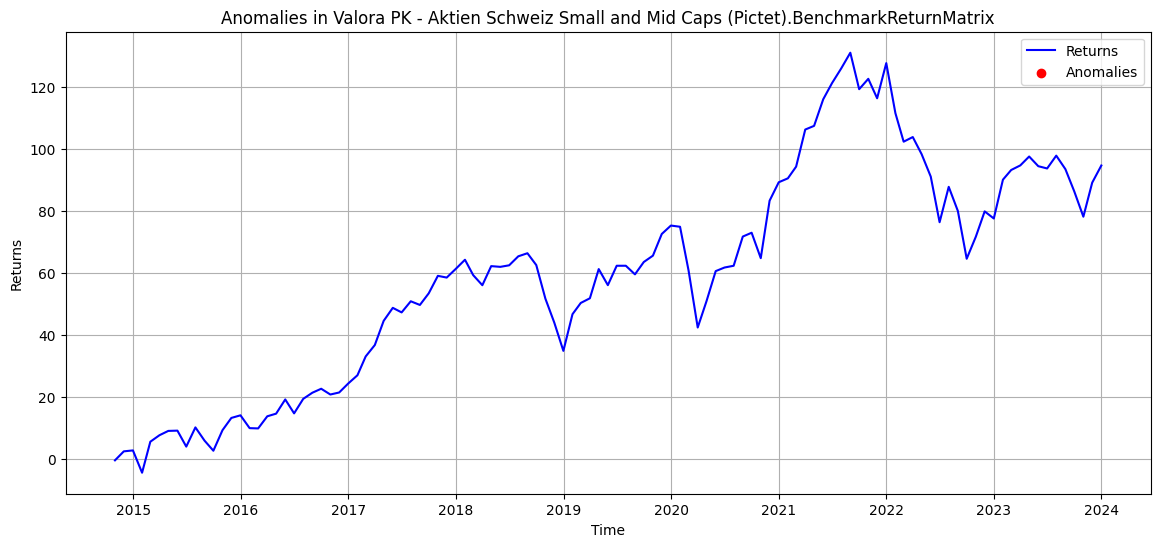

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def detect_anomalies_zscore(data_matrices, threshold=2.5):
    """
    Detect anomalies in benchmark returns using the Z-score method.

    Parameters:
    - data_matrices: dict, containing BenchmarkReturnMatrix.
    - threshold: float, Z-score threshold for anomaly detection.

    Returns:
    - anomalies: DataFrame with anomaly flags for each benchmark.
    """
    benchmark_returns = data_matrices['BenchmarkReturnMatrix']

    # Calculate mean and standard deviation
    mean = benchmark_returns.mean()
    std = benchmark_returns.std()

    # Compute Z-scores
    z_scores = (benchmark_returns - mean) / std

    # Flag anomalies
    anomalies = (np.abs(z_scores) > threshold).astype(int)  # 1 indicates anomaly
    return anomalies

# Visualization of anomalies
def plot_anomalies(benchmark_returns, anomalies, benchmark_name):
    """
    Plot benchmark returns with anomalies highlighted.

    Parameters:
    - benchmark_returns: Series, returns of a specific benchmark.
    - anomalies: Series, anomaly flags for the benchmark.
    - benchmark_name: str, name of the benchmark.
    """
    plt.figure(figsize=(14, 6))
    plt.plot(benchmark_returns.index, benchmark_returns, label="Returns", color="blue")
    plt.scatter(benchmark_returns.index[anomalies == 1],
                benchmark_returns[anomalies == 1],
                color="red", label="Anomalies", zorder=5)
    plt.title(f"Anomalies in {benchmark_name}")
    plt.xlabel("Time")
    plt.ylabel("Returns")
    plt.legend()
    plt.grid()
    plt.show()

# Main execution block
if __name__ == "__main__":
    # Load the data
    data_matrices = load_data(file_path)

    if data_matrices:
        # Detect anomalies
        anomalies = detect_anomalies_zscore(data_matrices, threshold=2.5)

        # Example: Plot anomalies for the first benchmark
        benchmark_name = data_matrices['BenchmarkReturnMatrix'].columns[0]
        benchmark_returns = data_matrices['BenchmarkReturnMatrix'][benchmark_name]
        anomaly_flags = anomalies[benchmark_name]
        plot_anomalies(benchmark_returns, anomaly_flags, benchmark_name)
    else:
        print("Failed to load data. Please check file path and structure.")



Anomalies detected using Isolation Forest:
Anomaly_Flag
 1    109
-1      2
Name: count, dtype: int64


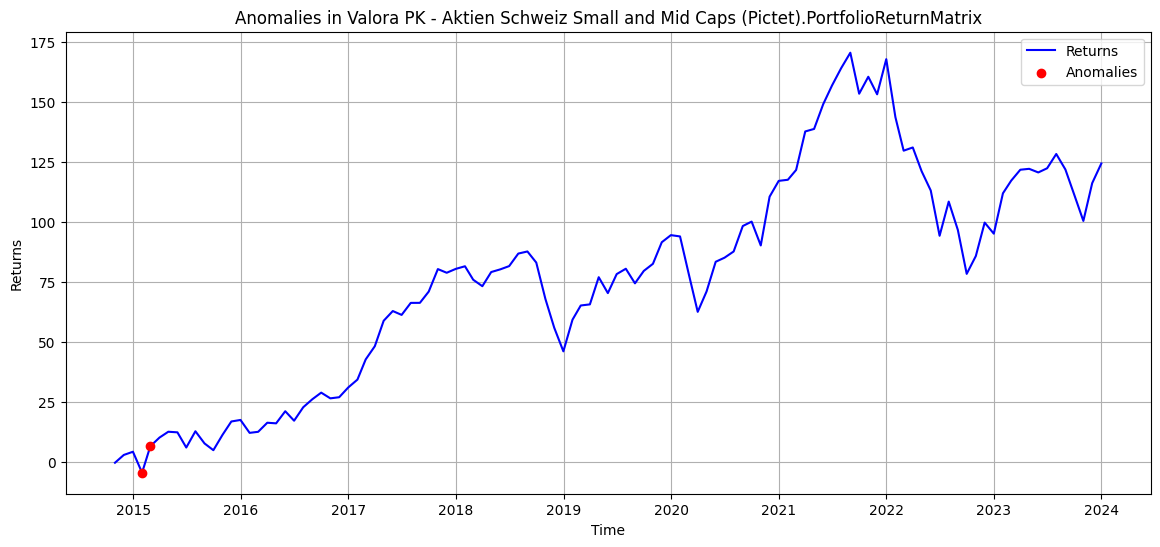

In [ ]:
from sklearn.ensemble import IsolationForest
import pandas as pd
import matplotlib.pyplot as plt

def detect_anomalies_isolation_forest_multivariate(data_matrices, contamination=0.01):
    """
    Detect anomalies in returns using Isolation Forest, considering all portfolio and benchmark returns.

    Parameters:
    - data_matrices: dict, containing PortfolioReturnMatrix and BenchmarkReturnMatrix.
    - contamination: float, proportion of anomalies expected in the data.

    Returns:
    - anomalies: DataFrame with anomaly flags for each time index.
    """
    # Combine portfolio and benchmark returns into a single DataFrame
    combined_returns = pd.concat(
        [data_matrices['PortfolioReturnMatrix'], data_matrices['BenchmarkReturnMatrix']],
        axis=1
    ).dropna()  # Drop rows with missing values

    # Train Isolation Forest model
    model = IsolationForest(contamination=contamination, random_state=42)
    model.fit(combined_returns)

    # Predict anomalies (-1 indicates anomaly)
    anomaly_flags = model.predict(combined_returns)

    # Add anomaly flags to the original DataFrame
    anomalies = pd.DataFrame(
        anomaly_flags,
        index=combined_returns.index,
        columns=['Anomaly_Flag']
    )
    return combined_returns, anomalies

# Visualization of anomalies in a specific benchmark or portfolio
def plot_anomalies_multivariate(combined_returns, anomalies, column_name):
    """
    Plot returns with anomalies highlighted for a specific column.

    Parameters:
    - combined_returns: DataFrame, combined portfolio and benchmark returns.
    - anomalies: DataFrame, anomaly flags.
    - column_name: str, name of the column to visualize.
    """
    plt.figure(figsize=(14, 6))
    plt.plot(combined_returns.index, combined_returns[column_name], label="Returns", color="blue")
    plt.scatter(
        combined_returns.index[anomalies['Anomaly_Flag'] == -1],
        combined_returns[column_name][anomalies['Anomaly_Flag'] == -1],
        color="red", label="Anomalies", zorder=5
    )
    plt.title(f"Anomalies in {column_name}")
    plt.xlabel("Time")
    plt.ylabel("Returns")
    plt.legend()
    plt.grid()
    plt.show()

# Main execution block
if __name__ == "__main__":
    # Load the data
    data_matrices = load_data(file_path)

    if data_matrices:
        # Detect anomalies
        combined_returns, anomalies = detect_anomalies_isolation_forest_multivariate(data_matrices, contamination=0.01)

        # Display anomalies summary
        print("Anomalies detected using Isolation Forest:")
        print(anomalies['Anomaly_Flag'].value_counts())  # Count normal (-1) vs anomalies (1)

        # Example: Plot anomalies for a specific portfolio or benchmark
        column_name = combined_returns.columns[0]  # Replace with desired column
        plot_anomalies_multivariate(combined_returns, anomalies, column_name)
    else:
        print("Failed to load data. Please check file path and structure.")



In [ ]:
def validate_anomalies_visual(combined_returns, anomalies, column_name, window=30):
    """
    Validate anomalies by visualizing them with rolling statistics.

    Parameters:
    - combined_returns: DataFrame, combined portfolio and benchmark returns.
    - anomalies: DataFrame, anomaly flags.
    - column_name: str, name of the column to visualize.
    - window: int, rolling window size for statistics.
    """
    # Calculate rolling statistics
    rolling_mean = combined_returns[column_name].rolling(window=window).mean()
    rolling_std = combined_returns[column_name].rolling(window=window).std()

    # Plot returns with rolling stats and anomalies
    plt.figure(figsize=(14, 6))
    plt.plot(combined_returns.index, combined_returns[column_name], label="Returns", color="blue")
    plt.plot(combined_returns.index, rolling_mean, label=f"Rolling Mean ({window} days)", color="green", linestyle="--")
    plt.fill_between(
        combined_returns.index,
        rolling_mean - 2 * rolling_std,
        rolling_mean + 2 * rolling_std,
        color="green", alpha=0.2, label="±2 Std Dev"
    )
    plt.scatter(
        combined_returns.index[anomalies['Anomaly_Flag'] == -1],
        combined_returns[column_name][anomalies['Anomaly_Flag'] == -1],
        color="red", label="Anomalies", zorder=5
    )
    plt.title(f"Anomaly Validation: {column_name}")
    plt.xlabel("Time")
    plt.ylabel("Returns")
    plt.legend()
    plt.grid()
    plt.show()

# Example usage for validation
if __name__ == "__main__":
    # Ensure anomalies and combined_returns are available
    validate_anomalies_visual(combined_returns, anomalies, column_name="Benchmark_1", window=30)


KeyError: 'Benchmark_1'

In [ ]:
def validate_anomalies_statistical(combined_returns, anomalies, column_name):
    """
    Validate anomalies by comparing their distribution with non-anomalous data.

    Parameters:
    - combined_returns: DataFrame, combined portfolio and benchmark returns.
    - anomalies: DataFrame, anomaly flags.
    - column_name: str, name of the column to validate.
    """
    # Separate anomalous and non-anomalous points
    anomaly_data = combined_returns[column_name][anomalies['Anomaly_Flag'] == -1]
    normal_data = combined_returns[column_name][anomalies['Anomaly_Flag'] == 1]

    # Perform statistical comparison (e.g., mean difference)
    mean_anomalies = anomaly_data.mean()
    mean_normal = normal_data.mean()
    print(f"Mean of anomalies: {mean_anomalies}")
    print(f"Mean of normal data: {mean_normal}")

    # Perform t-test
    from scipy.stats import ttest_ind
    t_stat, p_value = ttest_ind(anomaly_data, normal_data, equal_var=False)
    print(f"T-test results: t-statistic = {t_stat}, p-value = {p_value}")

    # Visualize distributions
    plt.figure(figsize=(10, 6))
    sns.histplot(normal_data, color="blue", kde=True, label="Normal Data", stat="density")
    sns.histplot(anomaly_data, color="red", kde=True, label="Anomalies", stat="density")
    plt.title(f"Distribution Comparison: {column_name}")
    plt.xlabel("Returns")
    plt.ylabel("Density")
    plt.legend()
    plt.grid()
    plt.show()
